# Question 1: Train linear regression on a dataset. Show where it fails. Apply polynomial regression and compare results using plots. Write a short explanation.

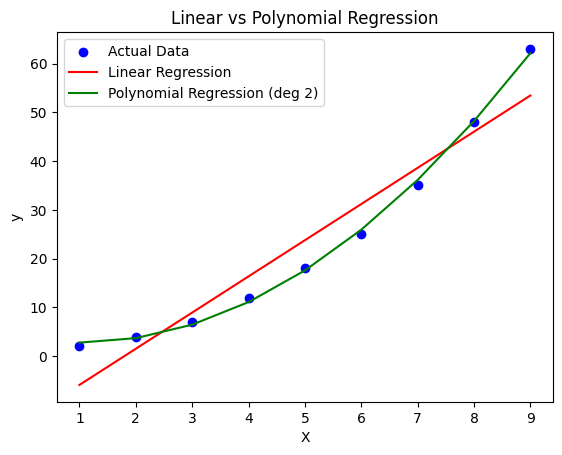

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Step 1: Create a sample dataset (non-linear / curved)
X = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
y = np.array([2, 4, 7, 12, 18, 25, 35, 48, 63])  # Non-linear relationship

# Step 2: Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
y_pred_lin = lin_reg.predict(X)

# Step 3: Train Polynomial Regression (degree 2)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)
poly_reg = LinearRegression()
poly_reg.fit(X_poly, y)
y_pred_poly = poly_reg.predict(X_poly)

# Step 4: Plotting
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred_lin, color='red', label='Linear Regression')
plt.plot(X, y_pred_poly, color='green', label='Polynomial Regression (deg 2)')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.show()

# Explanation:
Explanation
1. Dataset: We created a non-linear dataset where y increases faster than X.
2. Linear Regression:
 * Fits a straight line (red line).
 * Fails to capture the curve in the data.
 * High errors for larger X values.
3. Polynomial Regression:
 * Fits a curve (green line) using polynomial features (degree 2).
 * Captures the non-linear trend.
 * Predictions are much closer to actual values.

Conclusion:
Linear regression works well for straight-line relationships, but fails on curved/non-linear data. Polynomial regression transforms the input to capture curves, improving prediction accuracy.

# Question 2: Train logistic regression on a binary dataset. Plot decision boundary. Show predicted probabilities. Explain why logistic regression is suitable for classification.

Predicted probabilities: [0.01639402 0.0509552  0.14745414 0.35780349 0.64219157 0.85254316
 0.94904376 0.98360563]


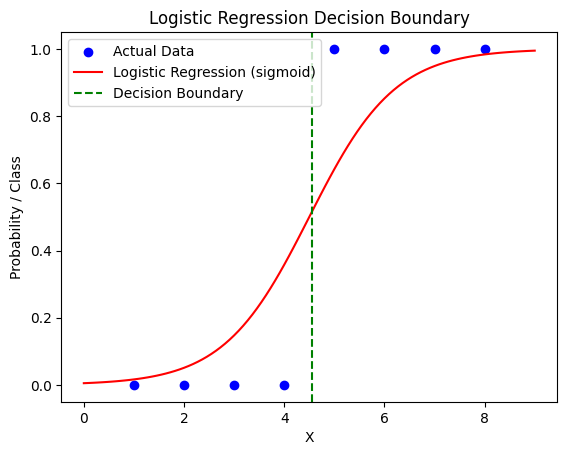

In [2]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Step 1: Create a simple binary dataset
X = np.array([[1], [2], [3], [4], [5], [6], [7], [8]])
y = np.array([0, 0, 0, 0, 1, 1, 1, 1])  # Binary labels

# Step 2: Train Logistic Regression
model = LogisticRegression()
model.fit(X, y)

# Step 3: Predict probabilities
y_prob = model.predict_proba(X)[:, 1]  # Probability of class 1
print("Predicted probabilities:", y_prob)

# Step 4: Plot data and decision boundary
plt.scatter(X, y, color='blue', label='Actual Data')

# Plot logistic regression curve (sigmoid)
X_test = np.linspace(0, 9, 100).reshape(-1, 1)
y_sigmoid = model.predict_proba(X_test)[:, 1]
plt.plot(X_test, y_sigmoid, color='red', label='Logistic Regression (sigmoid)')

# Decision boundary: where probability = 0.5
decision_boundary = X_test[np.where(y_sigmoid >= 0.5)[0][0]]
plt.axvline(x=decision_boundary, color='green', linestyle='--', label='Decision Boundary')

plt.xlabel('X')
plt.ylabel('Probability / Class')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

# Explanation:
Explanation 
1. Binary Dataset: Labels are either 0 or 1. Logistic regression predicts probabilities for each class.
2. Predicted Probabilities: Logistic regression uses the sigmoid function to output values between 0 and 1.
3.  Boundary: The model classifies data as 1 if probability ≥ 0.5 and 0 if probability < 0.5.
4. Why Logistic Regression is Suitable for Classification:
   * Outputs probabilities, not just labels.
   * Works well for binary and multi-class problems.
   * Provides interpretable decision boundaries.
   * Models the relationship between features and probability of class membership.

Conclusion: Logistic regression transforms linear combinations of features into probabilities, making it ideal for classification problems where we want to predict class labels.

# Question 3: Train multi-class logistic regression on the Iris dataset. Report accuracy and confusion matrix. Visualize prediction confidence. Explain model performance.

Accuracy: 1.0
Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


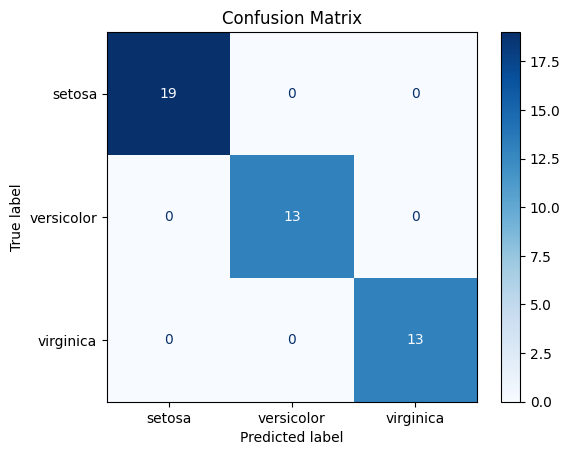

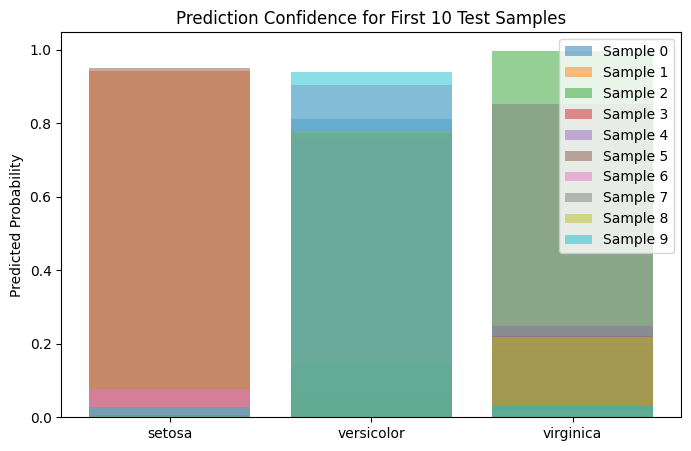

In [4]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data  # Features
y = iris.target  # Target labels (3 classes)

# Step 2: Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train Multi-class Logistic Regression
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

# Step 4: Predict on test data
y_pred = model.predict(X_test)

# Step 5: Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Step 6: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

# Step 7: Visualize prediction probabilities (confidence)
y_prob = model.predict_proba(X_test)  # Probabilities for each class

# Example: Plot prediction confidence for first 10 test samples
plt.figure(figsize=(8,5))
for i in range(10):
    plt.bar(range(3), y_prob[i], alpha=0.5, label=f'Sample {i}')
plt.xticks([0,1,2], iris.target_names)
plt.ylabel('Predicted Probability')
plt.title('Prediction Confidence for First 10 Test Samples')
plt.legend()
plt.show()

# Explanation:
Explanation 
1. Dataset: Iris dataset has 3 classes: setosa, versicolor, virginica.
2. Multi-class Logistic Regression:
   * multi_class='multinomial' uses softmax function to predict probabilities for all classes.
   * solver='lbfgs' is suitable for multinomial classification.
3. Accuracy: Shows the proportion of correct predictions on test data.
4. Confusion Matrix: Shows how many samples of each class are correctly or incorrectly predicted, helping to identify misclassifications.
5. Prediction Confidence:
   * predict_proba() gives probability of each sample belonging to each class.
   * High probability → model is confident; low probability → less confident.
6. Model Performance:
   * High accuracy (usually >90% on Iris dataset) indicates the model learns class boundaries well.
   * Confusion matrix may show occasional misclassification between similar classes (e.g., versicolor and virginica).
   * Logistic regression provides both class labels and confidence scores, which is useful for decision-making.

# Question 4: Apply k-means clustering on a 2D dataset. Experiment with different values of K. Visualize clusters and centroids. Explain how K affects clustering.


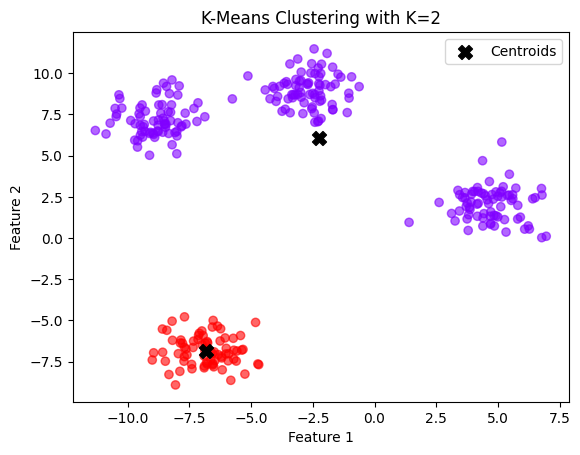

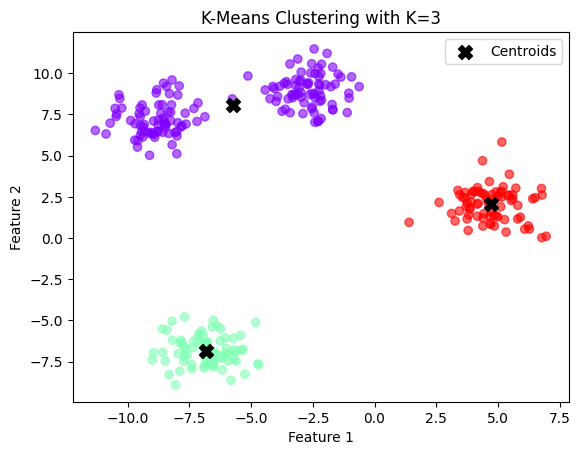

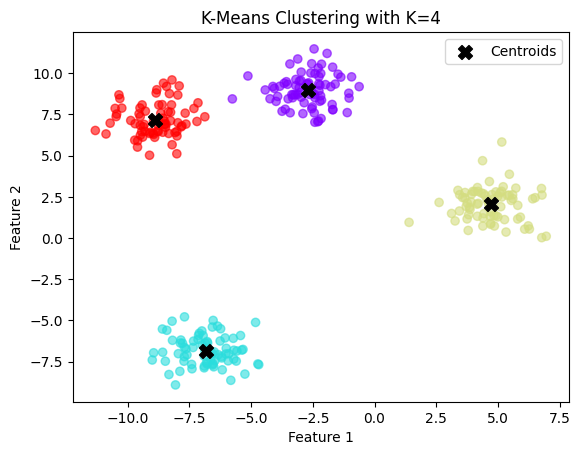

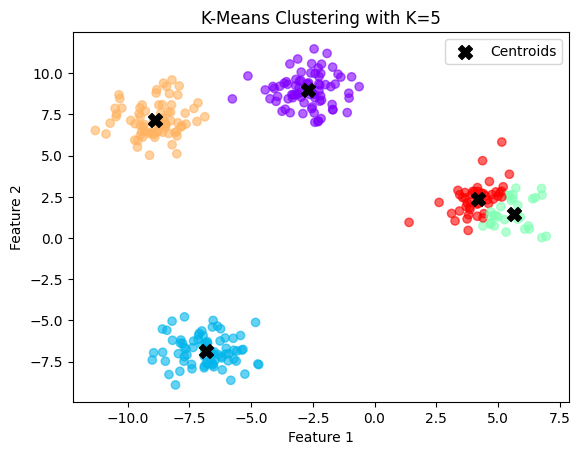

In [7]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Step 1: Create a synthetic 2D dataset
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# Function to apply k-means and plot clusters
def plot_kmeans(X, n_clusters):
    model = KMeans(n_clusters=n_clusters, random_state=42)
    model.fit(X)
    
    labels = model.labels_
    centroids = model.cluster_centers_
    
    # Plot clusters
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1], color='black', marker='X', s=100, label='Centroids')
    plt.title(f'K-Means Clustering with K={n_clusters}')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

# Step 2: Experiment with different K values
for k in [2, 3, 4, 5]:
    plot_kmeans(X, k)

# Explanation:
Explanation 
1. 2D Dataset:
   * make_blobs generates 2D points grouped around centers.
2. K-Means Clustering:
   * Divides the dataset into K clusters.
   * Each cluster has a centroid (black X in the plots).
   * Each point is assigned to the nearest centroid.
3. Effect of K:
   * Too small K: Clusters are merged; distinct groups may be combined.
   * Correct K: Clusters match natural groupings (e.g., K=4 for our dataset).
   * Too large K: Clusters are split unnecessarily; points may form tiny clusters.
4. Visualization:
   * Scatter plot shows points colored by cluster.
   * Centroids show the “center” of each cluster.
   * Comparing different K values helps decide the optimal number of clusters.

Conclusion:
The value of K affects how clusters are formed.
* A small K → underfitting clusters (groups merged).
* A large K → overfitting clusters (groups split).
* Choosing the right K (using methods like Elbow method) ensures meaningful clustering.